# Trash Detection — Local & Colab-ready notebook

This notebook builds and trains a combined trash detector. It now works on both Colab and local machines (Windows / Linux / macOS).

Folders expected under the repository root (or set the environment variable PROJECT_DIR to the repo root):
- Images_Dataset/Algae (include train/valid/test subfolders)
- Images_Dataset/PlasticBottles_Garbage (images/ and labels/)
- Images_Dataset/underwater_garbage (images/, labels/, data.yaml)
- models/trash_detection (contains build_dataset.py, train.py, infer.py)

If running locally, run this notebook from the repository root so the script can auto-detect `Images_Dataset`. Alternatively set `PROJECT_DIR` env var to point to the repo root.


In [3]:
# 1) Install and environment checks (works on Colab or locally)
import sys
import subprocess
import importlib
import os
from pathlib import Path
import torch

# Ensure required packages are installed (will install only if missing)
def ensure_pkg(module_name, install_name=None):
    try:
        importlib.import_module(module_name)
    except Exception:
        pkg = install_name or module_name
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for mod, pkg in [("ultralytics", "ultralytics"), ("yaml", "pyyaml"), ("matplotlib", "matplotlib"), ("PIL", "Pillow")]:
    ensure_pkg(mod, pkg)

print('Python', sys.version.split()[0])
print('torch.cuda available:', torch.cuda.is_available())

# Determine PROJECT_DIR automatically for local runs
# Priority: environment variable PROJECT_DIR > current working directory (if contains Images_Dataset) > search up to 4 parents
PROJECT_DIR = Path(os.environ.get('PROJECT_DIR', Path.cwd()))
if not (PROJECT_DIR / 'Images_Dataset').exists():
    p = Path.cwd()
    found = False
    for _ in range(4):
        if (p / 'Images_Dataset').exists():
            PROJECT_DIR = p
            found = True
            break
        if p.parent == p:
            break
        p = p.parent
    if not found:
        print('Warning: Could not find "Images_Dataset" in current or parent folders. Set PROJECT_DIR env var or run this notebook from the repo root.')

print('PROJECT_DIR:', PROJECT_DIR)


Python 3.12.0
torch.cuda available: False
PROJECT_DIR: c:\Users\divyj\Desktop\hackathons\hackVeda iilm


In [4]:
# 2) Prepare & build dataset (robust to Windows paths)
from pathlib import Path
import random
import yaml
import os

IMAGES_ROOT = PROJECT_DIR / 'Images_Dataset'
OUT_DIR = Path('models/trash_detection')
OUT_DIR.mkdir(parents=True, exist_ok=True)
DATASETS_DIR = OUT_DIR / 'datasets'
DATASETS_DIR.mkdir(parents=True, exist_ok=True)

# Read names from underwater_garbage/data.yaml
uw_yaml = IMAGES_ROOT / 'underwater_garbage' / 'data.yaml'
if not uw_yaml.exists():
    raise FileNotFoundError(f'Missing {uw_yaml} — place the dataset folders under {PROJECT_DIR}/Images_Dataset')
with open(uw_yaml) as f:
    uw_d = yaml.safe_load(f)
names = uw_d.get('names')
if isinstance(names, dict):
    max_idx = max(int(k) for k in names.keys())
    names = [names.get(i, names.get(str(i), f'cls{i}')) for i in range(max_idx+1)]

# Collect images
train_images = []
val_images = []
test_images = []

# Algae: uses train/valid/test
algae_base = IMAGES_ROOT / 'Algae'
for split, out_list in [('train', train_images), ('valid', val_images), ('test', test_images)]:
    imgs_dir = algae_base / split / 'images'
    if imgs_dir.exists():
        imgs = sorted(imgs_dir.rglob('*.jpg')) + sorted(imgs_dir.rglob('*.png'))
        out_list += imgs

# Underwater (has images/train, images/val, images/test)
uw_base = IMAGES_ROOT / 'underwater_garbage' / 'images'
for split, out_list in [('train', train_images), ('val', val_images), ('test', test_images)]:
    imgs_dir = uw_base / split
    if imgs_dir.exists():
        imgs = sorted(imgs_dir.rglob('*.jpg')) + sorted(imgs_dir.rglob('*.png'))
        out_list += imgs

# PlasticBottles_Garbage (images/ — we will split)
pb_base = IMAGES_ROOT / 'PlasticBottles_Garbage' / 'images'
pb_imgs = sorted(pb_base.rglob('*.jpg')) + sorted(pb_base.rglob('*.png')) if pb_base.exists() else []
random.Random(42).shuffle(pb_imgs)
n = len(pb_imgs)
if n:
    n_train = int(n * 0.8)
    n_val = int(n * 0.1)
    pb_train = pb_imgs[:n_train]
    pb_val = pb_imgs[n_train:n_train + n_val]
    pb_test = pb_imgs[n_train + n_val:]
    train_images += pb_train
    val_images += pb_val
    test_images += pb_test

# Helper: robustly create label path for an image regardless of OS path separator
def label_for_image(img_path):
    p = Path(img_path)
    parts = list(p.parts)
    try:
        idx = parts.index('images')
        parts[idx] = 'labels'
        return Path(*parts).with_suffix('.txt')
    except ValueError:
        # fallback replacements for common patterns
        s = str(p).replace('/images/', '/labels/').replace('\\images\\', '\\labels\\')
        return Path(s).with_suffix('.txt')

# Filter images that have corresponding label files
def filter_with_label(imgs):
    out = []
    for p in imgs:
        lbl = label_for_image(p)
        if lbl.exists():
            out.append(p.resolve())
    return out

train_images = filter_with_label(train_images)
val_images = filter_with_label(val_images)
test_images = filter_with_label(test_images)

# write lists (one absolute path per line)
train_list = DATASETS_DIR / 'train.txt'
val_list = DATASETS_DIR / 'val.txt'
test_list = DATASETS_DIR / 'test.txt'
for lst, path in [(train_images, train_list), (val_images, val_list), (test_images, test_list)]:
    with open(path, 'w') as f:
        for p in lst:
            f.write(p.as_posix() + '\n')

# write combined data.yaml
combined_yaml = OUT_DIR / 'data.yaml'
data = {
    'train': train_list.resolve().as_posix(),
    'val': val_list.resolve().as_posix(),
    'test': test_list.resolve().as_posix(),
    'nc': len(names),
    'names': names
}
with open(combined_yaml, 'w') as f:
    yaml.safe_dump(data, f, sort_keys=False)

print('Wrote:', train_list, val_list, test_list, combined_yaml)
print('train/val/test counts:', len(train_images), len(val_images), len(test_images))


Wrote: models\trash_detection\datasets\train.txt models\trash_detection\datasets\val.txt models\trash_detection\datasets\test.txt models\trash_detection\data.yaml
train/val/test counts: 4147 1154 636


In [5]:
# 3) Inspect data.yaml and split sizes
import yaml
from pathlib import Path
p = Path('models/trash_detection/data.yaml')
if not p.exists():
    raise FileNotFoundError('data.yaml not found — run the build step')
d = yaml.safe_load(p.read_text())
print('nc:', d['nc'])
print('first names:', d['names'][:10])
for s in ['train','val','test']:
    f = Path(d[s])
    n = sum(1 for _ in f.open()) if f.exists() else 0
    print(s, n)


nc: 17
first names: ['Mask', 'can', 'cellphone', 'electronics', 'gbottle', 'glove', 'metal', 'misc', 'net', 'pbag']
train 4147
val 1154
test 636


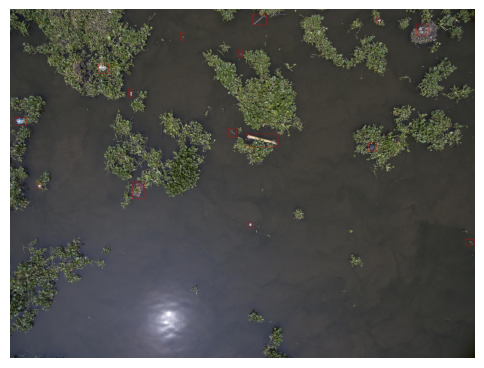

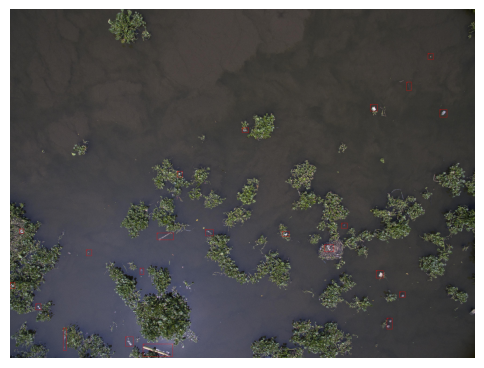

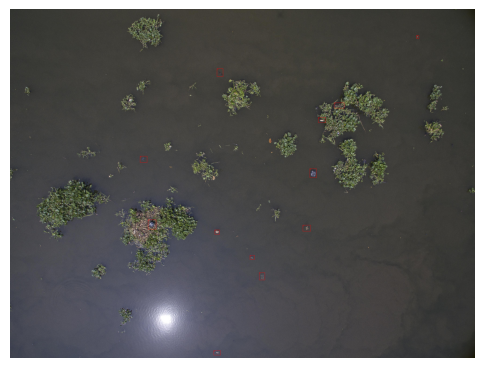

In [6]:
# 4) Preview up to 3 train images with YOLO-format boxes
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from pathlib import Path

train_list = Path('models/trash_detection/datasets/train.txt')
if not train_list.exists():
    raise FileNotFoundError('train list not found; run build step')

lines = [l.strip() for l in train_list.open() if l.strip()][:3]
for img_path in lines:
    img = Image.open(img_path).convert('RGB')
    w,h = img.size
    label_path = Path(str(img_path).replace('/images/', '/labels/')).with_suffix('.txt')
    draw = ImageDraw.Draw(img)
    if label_path.exists():
        for line in label_path.open():
            cls, xc, yc, ww, hh = line.split()[:5]
            xc, yc, ww, hh = map(float, (xc, yc, ww, hh))
            x1 = (xc - ww/2)*w; y1 = (yc - hh/2)*h
            x2 = (xc + ww/2)*w; y2 = (yc + hh/2)*h
            draw.rectangle([x1,y1,x2,y2], outline='red', width=2)
            draw.text((x1,y1), cls, fill='red')
    plt.figure(figsize=(6,6)); plt.imshow(img); plt.axis('off')


In [ ]:
# 5) Training (inline using ultralytics)
from ultralytics import YOLO
from pathlib import Path
import torch

data_yaml = Path('models/trash_detection/data.yaml')
if not data_yaml.exists():
    raise FileNotFoundError('data.yaml not found — run the build step')

# Auto-select device: use GPU if available, otherwise CPU (and adjust batch size)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)
if device == 'cpu':
    print('CPU detected — use small batch size to avoid OOM')
    batch = 4
    epochs = 1
else:
    batch = 8
    epochs = 1

model = YOLO('yolov8n.pt')
model.train(data=str(data_yaml), epochs=epochs, imgsz=640, batch=batch, device=device, name='trash_local', project='runs/trash')
print('Training finished (smoke run).')


In [ ]:
# 6) Inference (inline using ultralytics)
from ultralytics import YOLO
from pathlib import Path
import glob

# Try to find trained weights automatically under runs/trash
weights_candidates = list(Path('runs/trash').rglob('weights/best.pt')) + list(Path('runs/trash').rglob('weights/last.pt'))
weights_path = weights_candidates[0] if weights_candidates else Path('runs/trash/trash_colab/weights/best.pt')
if not weights_path.exists():
    print('No trained weights found at', weights_path, '- run training and then re-run this cell')
else:
    print('Using weights:', weights_path)
    model = YOLO(str(weights_path))
    # pass a text file with test images or a directory
    source = 'models/trash_detection/datasets/test.txt'
    if not Path(source).exists():
        # fallback: try directory of test images
        test_dir = Path('Images_Dataset') / 'underwater_garbage' / 'images' / 'test'
        if test_dir.exists():
            source = str(test_dir)
    res = model.predict(source=source, save=True, device='cuda' if model.model.cuda else 'cpu')
    print('Inference done; check results under runs/predict or runs/trash')


## Notes & local-run checklist

- When running locally, ensure you have a Python environment with access to the internet for package/model downloads, or pre-download weights.
- You can set the repository root via the environment variable `PROJECT_DIR` or run the notebook from the repo root so `Images_Dataset/` is found.
- For CPU runs, training uses small batch sizes and short epochs by default to avoid memory issues; change `device`, `batch`, and `epochs` in the training cell to suit your hardware.
- For long runs, consider running training from `models/trash_detection/train.py` or using a GPU-enabled machine.

Recommended workflow (local):
1. Create and activate a virtual environment and run the first cell to auto-install missing packages. ✅
2. Run the dataset build cell to generate `models/trash_detection/data.yaml` and dataset lists. ✅
3. Run a 1-epoch smoke training to verify everything, then increase epochs and batch size for GPU runs. ✅
4. Run the inference cell and inspect outputs under `runs/predict` or `runs/trash`.

If you hit any platform-specific path issues, let me know the error and I'll adjust the notebook further. 🔧
